In [1]:
#Import libraries

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os

In [2]:
#Set some simulation parameters

Nx = 64
Ny = 64
Nz = 64
Lx = 2*np.pi
Ly = 2*np.pi
Lz = 2
dx = Lx/Nx
dy = Ly/Ny
dz = Lz/Nz

zi = 1000
uscale = 0.4
x = np.arange(0,Nx)*dx
y = np.arange(0,Ny)*dy
z_uvp = np.arange(0,Nz)*dz + dz/2
z_w = np.arange(0,Nz)*dz

kvonk = 0.4
g_hat = 9.81*zi/(uscale**2)

In [3]:
#Set the path to the simulation and data

path = '/scratch/general/nfs1/u1450851/LES_Sims/'
sim = 't_hom_1ms_aniso_uvp_nosgs_RAV'
path_to_data = path + sim + '/data/'

nRAV_start = 19996
nRAV = 10
mom3D = dict(); mom2D = dict(); sc3D = dict(); sc2D = dict(); aniso = dict()

for i in range(0,nRAV):
    mom3D[str(nRAV_start + i)] = xr.open_dataarray(path_to_data + 'Momentum3D/Data_Momentum_' + str(nRAV_start + i) + '.nc')
    mom2D[str(nRAV_start + i)] = xr.open_dataarray(path_to_data + 'Momentum2D/Data_Momentum_2D_' + str(nRAV_start + i) + '.nc')
    sc3D[str(nRAV_start + i)] = xr.open_dataarray(path_to_data + 'Scalar3D/Data_Scalar_' + str(nRAV_start + i) + '.nc')
    sc2D[str(nRAV_start + i)] = xr.open_dataarray(path_to_data + 'Scalar2D/Data_Scalar_2D_' + str(nRAV_start + i) + '.nc')
    aniso[str(nRAV_start + i)] = xr.open_dataarray(path_to_data + 'Anisotropy/Data_Anisotropy_' + str(nRAV_start + i) + '.nc')


# Check surface variables

In [66]:
sc2D[str(19999)][42,44,4].values

array(0.05706885)

In [69]:
0.5*dz/sc2D[str(20000)][42,44,1].values

-5020379123.181432

In [67]:
a = 0.33
b = 0.41
c = 0.33
d = 0.057
n = 0.78
y = -0.5*dz/sc2D[str(19999)][42,44,1].values
yy = b ** (-3.0)
xx = (yy / a) ** (1.0 / 3.0)
psi_zero = -np.log(a) + (np.sqrt(3.0) * b * (a ** (1.0 / 3.0)) * (np.pi / 6.0))

psim = (
    np.log(a + yy)
    - (3.0 * b * (yy ** (1.0 / 3.0)))
    + ((b * (a ** (1.0 / 3.0)) / 2.0) * np.log(((1 + xx) ** 2) / (1 - xx + (xx ** 2))))
    + (np.sqrt(3.0) * b * (a ** (1.0 / 3.0)) * np.arctan(((2.0 * xx) - 1) / np.sqrt(3.0)))
    + psi_zero
)
phih = (c + (d*(y**n)))/(c+(y**n))

In [68]:
phih

0.05706884674131656

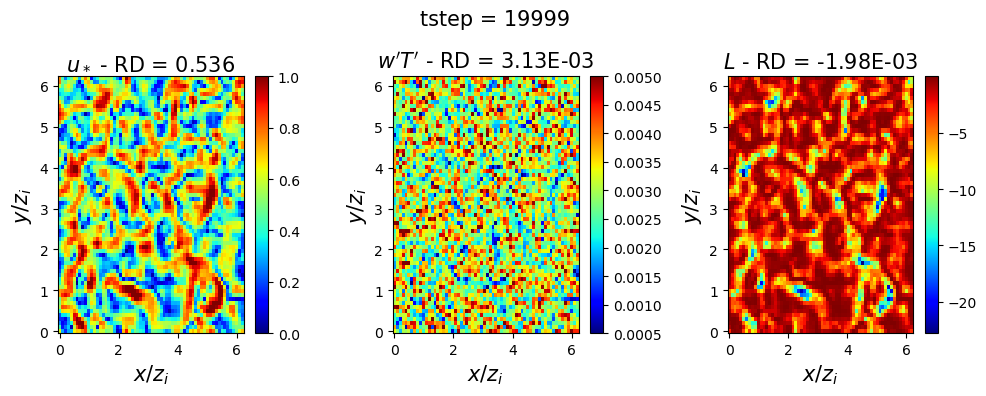

In [5]:
#Plot ustar,wT,L at the surface

tstep = 19999
ustar = mom2D[str(tstep)][:,:,0].values
wT = sc2D[str(tstep)][:,:,-1].values
L = sc2D[str(tstep)][:,:,1].values
T = np.mean(sc3D[str(tstep)][:,:,0,0].values)
L_rd = -(np.mean(ustar)**3)*T/(kvonk*g_hat*np.mean(wT))

fig,axs = plt.subplots(1,3,tight_layout=True,figsize=(10,4))

p = axs[0].pcolormesh(x,y,ustar.T,cmap='jet',vmin=0,vmax=1)
axs[0].set_xlabel(r"$x/z_i$",fontsize=15)
axs[0].set_ylabel(r"$y/z_i$",fontsize=15)
axs[0].set_title(r"$u_*$ - " + f"RD = {np.mean(ustar) :.03f}",fontsize=15)
cbar = plt.colorbar(p)

p = axs[1].pcolormesh(x,y,wT.T,cmap='jet',vmin=5E-4,vmax=5e-3)
axs[1].set_xlabel(r"$x/z_i$",fontsize=15)
axs[1].set_ylabel(r"$y/z_i$",fontsize=15)
axs[1].set_title(r"$w'T'$ - " + f"RD = {np.mean(wT) :.2E}",fontsize=15)
cbar = plt.colorbar(p)

p = axs[2].pcolormesh(x,y,(L*zi).T,cmap='jet')
axs[2].set_xlabel(r"$x/z_i$",fontsize=15)
axs[2].set_ylabel(r"$y/z_i$",fontsize=15)
axs[2].set_title(r"$L$ - " + f"RD = {L_rd :.2E}",fontsize=15)
cbar = plt.colorbar(p)

fig.suptitle(f'tstep = {tstep}',fontsize=15)

plt.show()

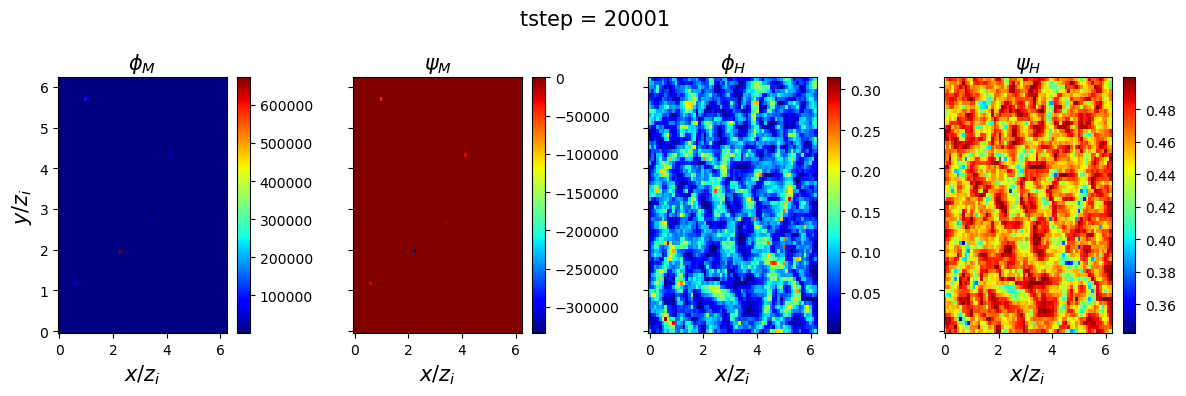

In [8]:
#Plot the surface scaling functions

tstep = 20001
phiM = sc2D[str(tstep)][:,:,2].values
psiM = sc2D[str(tstep)][:,:,3].values
phiH = sc2D[str(tstep)][:,:,4].values
psiH = sc2D[str(tstep)][:,:,5].values

fig,axs = plt.subplots(1,4,tight_layout=True,figsize=(12,4),sharey=True)

p = axs[0].pcolormesh(x,y,phiM.T,cmap='jet')
# axs[0].plot(x[42],y[44],'ko')
axs[0].set_xlabel(r"$x/z_i$",fontsize=15)
axs[0].set_ylabel(r"$y/z_i$",fontsize=15)
axs[0].set_title(r"$\phi_M$",fontsize=15)
cbar = plt.colorbar(p)

p = axs[1].pcolormesh(x,y,psiM.T,cmap='jet')
axs[1].set_xlabel(r"$x/z_i$",fontsize=15)
# axs[1].set_ylabel(r"$y/z_i$",fontsize=15)
axs[1].set_title(r"$\psi_M$",fontsize=15)
cbar = plt.colorbar(p)

p = axs[2].pcolormesh(x,y,phiH.T,cmap='jet')
axs[2].set_xlabel(r"$x/z_i$",fontsize=15)
# axs[2].set_ylabel(r"$y/z_i$",fontsize=15)
axs[2].set_title(r"$\phi_H$",fontsize=15)
cbar = plt.colorbar(p)

p = axs[3].pcolormesh(x,y,psiH.T,cmap='jet')
axs[3].set_xlabel(r"$x/z_i$",fontsize=15)
# axs[3].set_ylabel(r"$y/z_i$",fontsize=15)
axs[3].set_title(r"$\psi_H$",fontsize=15)
cbar = plt.colorbar(p)

fig.suptitle(f'tstep = {tstep}',fontsize=15)

plt.show()

In [148]:
np.argwhere(np.isinf(wT))

array([[42, 44]])

In [43]:
Tsfc = sc2D[str(20016)][:,:,-2].values
T1 = sc3D[str(20021)][:,:,0,0].values
wT_v2 = (Tsfc - T1)*kvonk*ustar/(phiH*np.log(0.5*dz/(0.01/zi))) 

In [51]:
sc3D[str(20022)][42,44,0,0].values

array(nan)

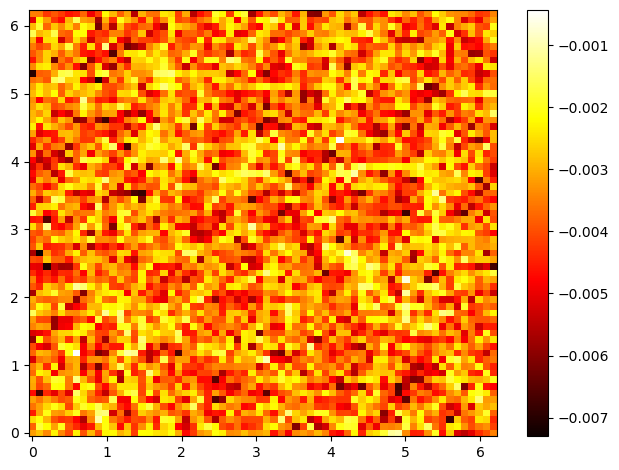

In [53]:
fig,axs = plt.subplots(1,1,tight_layout=True)
p = axs.pcolormesh(x,y,sc3D[str(20021)][:,:,0,7].T,cmap='hot')
cbar = plt.colorbar(p)
plt.show()

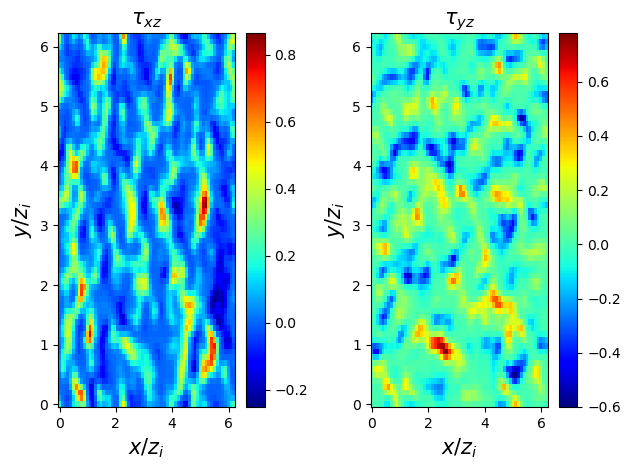

In [120]:
#Plot the SGS stresses xz and yz
tstep = 20021
txz = mom3D[str(tstep)][:,:,:,20].values
tyz = mom3D[str(tstep)][:,:,:,21].values

fig,axs = plt.subplots(1,2,tight_layout=True)

p = axs[0].pcolormesh(x,y,txz[:,:,0].T,cmap='jet')
axs[0].set_xlabel(r"$x/z_i$",fontsize=15)
axs[0].set_ylabel(r"$y/z_i$",fontsize=15)
axs[0].set_title(r"$\tau_{xz}$",fontsize=15)
cbar = plt.colorbar(p)

p = axs[1].pcolormesh(x,y,tyz[:,:,0].T,cmap='jet')
axs[1].set_xlabel(r"$x/z_i$",fontsize=15)
axs[1].set_ylabel(r"$y/z_i$",fontsize=15)
axs[1].set_title(r"$\tau_{yz}$",fontsize=15)
cbar = plt.colorbar(p)

plt.show()

# Compute phi in postprocess

In [9]:
import numpy as np

def compute_phi_anisotropy(Ll, wtl, yB, dz):
    
    nx, ny = Ll.shape
    phim3D = np.zeros((nx, ny), dtype=float)
    phih3D = np.zeros((nx, ny), dtype=float)

    # Extract needed slice from yB
    yB1 = yB[:, :, 0]  # Fortran index 1 → Python index 0

    # Initialize zeta
    zeta = (0.5 * dz) / Ll

    # Masks
    conv_mask = (Ll < 0.0) & (wtl[:, :] != 0.0)
    stab_mask = (Ll > 0.0) & (wtl[:, :] != 0.0)
    neut_mask = ~(conv_mask | stab_mask)

    # --- Convective scenario ---
    if np.any(conv_mask):
        b = 0.061
        c = 0.45 - 0.53 * yB1[conv_mask]
        n = -0.12 + 6.4 * yB1[conv_mask]
        abs_zeta_n = np.abs(zeta[conv_mask]) ** n

        a = np.where(yB1[conv_mask] > 0.6,
                     0.012,
                     0.24 - 0.38 * yB1[conv_mask])

        phim3D[conv_mask] = (a + b * abs_zeta_n) / (a + abs_zeta_n) \
                            + c * (np.abs(zeta[conv_mask]) ** (1.0 / 3.0))

        d = 0.48 + 1.8 * yB1[conv_mask]
        phih3D[conv_mask] = d * (((3.0 - 2.5 * zeta[conv_mask]) /
                                  (1.0 - 10.0 * zeta[conv_mask] + 50.0 * (zeta[conv_mask] ** 2))) ** (1.0 / 3.0))

    # --- Stable scenario ---
    if np.any(stab_mask):
        a = 0.76 + 1.5 * yB1[stab_mask]
        b = 6.3 - 4.3 * yB1[stab_mask]
        phim3D[stab_mask] = a + b * zeta[stab_mask]

        c = np.where(yB1[stab_mask] > 0.6,
                     0.34,
                     1.9 - 2.6 * yB1[stab_mask])
        d = 6.7 - 10.0 * yB1[stab_mask]
        phih3D[stab_mask] = c + d * zeta[stab_mask]

    # --- Neutral scenario ---
    phim3D[neut_mask] = 1.0
    phih3D[neut_mask] = 0.0

    return phim3D, phih3D

In [10]:
tstep = 19999
L = sc2D[str(tstep)][:,:,1].values
wT = sc2D[str(tstep)][:,:,-1].values
yB = aniso[str(tstep)][:,:,:,1].values

phiM,phiH = compute_phi_anisotropy(L,wT,yB,dz)

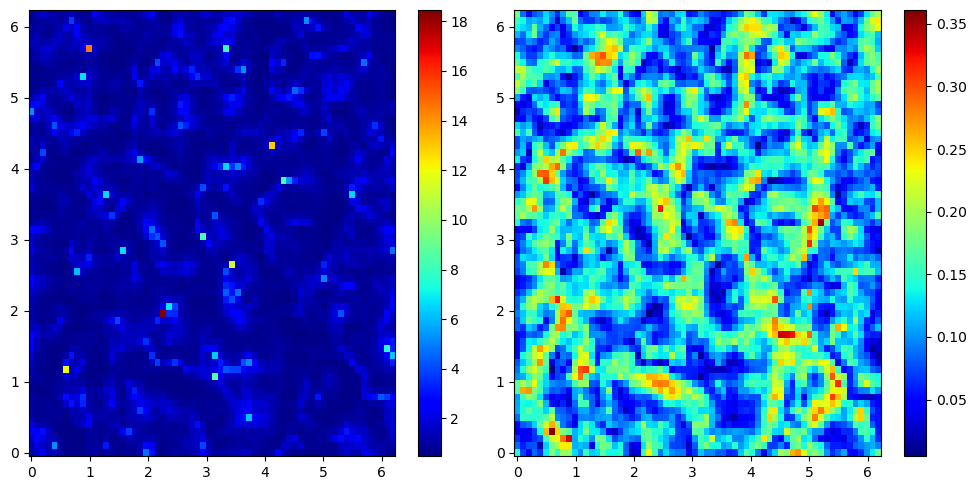

In [11]:
fig,axs = plt.subplots(1,2,tight_layout=True,figsize=(10,5))

p1 = axs[0].pcolormesh(x,y,phiM.T,cmap='jet')
p2 = axs[1].pcolormesh(x,y,phiH.T,cmap='jet')
cbar1 = plt.colorbar(p1)
cbar2 = plt.colorbar(p2)
plt.show()

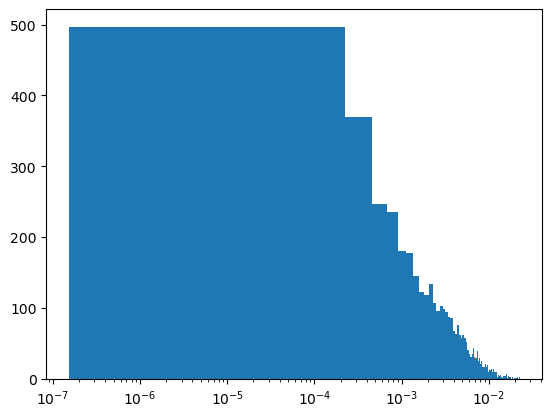

In [115]:
plt.hist(abs(L.flatten()),bins=100)
plt.xscale('log')

In [116]:
np.mean(L)

-0.003107169610031684

In [81]:
conv_mask = (L < 0.0) & (wT[:, :] != 0.0)

In [83]:
conv_mask

array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]])

In [84]:
np.any(conv_mask)

True

In [85]:
stab_mask = (L > 0.0) & (wT[:, :] != 0.0)

In [88]:
np.any(stab_mask)

False

In [90]:
neut_mask = ~(conv_mask | stab_mask)

In [91]:
np.any(neut_mask)

False

In [136]:
yB[24,36,0]

0.03919096373504994

In [169]:
b = 0.061
c = 0.45 - 0.53 * yB[24,36,0]
n = -0.12 + 6.4 * yB[24,36,0]
zeta = 0.5*dz/L[24,36]
abs_zeta_n = np.abs(zeta) ** n

a = 0.24 - 0.38 * yB[24,36,0]

phim = (a + b * abs_zeta_n) / (a + abs_zeta_n) \
                    + c * (np.abs(zeta) ** (1.0 / 3.0))

In [170]:
(np.abs(zeta) ** (1.0 / 3.0))

1.1518672149270988